# Email Parsing Experiments

## Objective

This notebook explores how to parse raw email files into a structured machine learning dataset.

Goals:
- extract email body
- extract metadata
- handle multipart emails
- clean HTML emails
- build structured dataset
- prepare emails for ML preprocessing

In [92]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import os
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from email import policy
from email.parser import BytesParser

In [93]:
# =========================================================
# RAW DATASET PATHS
# =========================================================

DATA_PATHS = {

    "ham": [

        "../data/raw/easy_ham_1",

        "../data/raw/easy_ham_2"
    ],

    "spam": [

        "../data/raw/spam_1",

        "../data/raw/spam_2"
    ]
}

DATA_PATHS

{'ham': ['../data/raw/easy_ham_1', '../data/raw/easy_ham_2'],
 'spam': ['../data/raw/spam_1', '../data/raw/spam_2']}

In [94]:
# =========================================================
# LOAD SAMPLE EMAIL
# =========================================================

sample_path = (

    "../data/raw/easy_ham_1/"
    + os.listdir(
        "../data/raw/easy_ham_1"
    )[0]
)

sample_path

'../data/raw/easy_ham_1/00001.7c53336b37003a9286aba55d2945844c'

In [95]:
# =========================================================
# READ RAW EMAIL CONTENT
# =========================================================

with open(

    sample_path,

    "rb"

) as f:

    raw_email = f.read()

print(

    raw_email[:2000]
)

b'From exmh-workers-admin@redhat.com  Thu Aug 22 12:36:23 2002\nReturn-Path: <exmh-workers-admin@spamassassin.taint.org>\nDelivered-To: zzzz@localhost.netnoteinc.com\nReceived: from localhost (localhost [127.0.0.1])\n\tby phobos.labs.netnoteinc.com (Postfix) with ESMTP id D03E543C36\n\tfor <zzzz@localhost>; Thu, 22 Aug 2002 07:36:16 -0400 (EDT)\nReceived: from phobos [127.0.0.1]\n\tby localhost with IMAP (fetchmail-5.9.0)\n\tfor zzzz@localhost (single-drop); Thu, 22 Aug 2002 12:36:16 +0100 (IST)\nReceived: from listman.spamassassin.taint.org (listman.spamassassin.taint.org [66.187.233.211]) by\n    dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g7MBYrZ04811 for\n    <zzzz-exmh@spamassassin.taint.org>; Thu, 22 Aug 2002 12:34:53 +0100\nReceived: from listman.spamassassin.taint.org (localhost.localdomain [127.0.0.1]) by\n    listman.redhat.com (Postfix) with ESMTP id 8386540858; Thu, 22 Aug 2002\n    07:35:02 -0400 (EDT)\nDelivered-To: exmh-workers@listman.spamassassin.taint.org\nRecei

In [96]:
# =========================================================
# PARSE EMAIL OBJECT
# =========================================================

with open(

    sample_path,

    "rb"

) as f:

    msg = BytesParser(

        policy=policy.default

    ).parse(f)

msg

In [97]:
# =========================================================
# EMAIL HEADERS
# =========================================================

print(

    "Subject:",
    msg.get("Subject")
)

print(

    "From:",
    msg.get("From")
)

print(

    "To:",
    msg.get("To")
)

print(

    "Date:",
    msg.get("Date")
)

Subject: Re: New Sequences Window
From: Robert Elz <kre@munnari.OZ.AU>
To: Chris Garrigues <cwg-dated-1030377287.06fa6d@DeepEddy.Com>
Date: Thu, 22 Aug 2002 18:26:25 +0700


In [98]:
# =========================================================
# MULTIPART CHECK
# =========================================================

msg.is_multipart()

False

In [99]:
# =========================================================
# EMAIL BODY EXTRACTION
# =========================================================

def extract_body(msg):

    """
    Extracts email body content.

    Logic:
    - prefer plain text
    - fallback to HTML
    - ignore decoding errors

    Args:
        msg:
            Parsed email object.

    Returns:
        str:
            Clean email body.
    """

    body = ""

    try:

        # =============================================
        # HANDLE MULTIPART EMAILS
        # =============================================

        if msg.is_multipart():

            for part in msg.walk():

                content_type = (

                    part.get_content_type()
                )

                payload = (

                    part.get_payload(
                        decode=True
                    )
                )

                if payload:

                    decoded = payload.decode(

                        errors="ignore"
                    )

                    # =================================
                    # PREFER PLAIN TEXT
                    # =================================

                    if content_type == "text/plain":

                        body += decoded

                    # =================================
                    # FALLBACK TO HTML
                    # =================================

                    elif (

                        content_type == "text/html"
                        and len(body.strip()) == 0
                    ):

                        clean_html = re.sub(

                            r"<[^>]+>",

                            " ",

                            decoded
                        )

                        body += clean_html

        # =============================================
        # HANDLE SINGLEPART EMAILS
        # =============================================

        else:

            payload = msg.get_payload(
                decode=True
            )

            if payload:

                body = payload.decode(
                    errors="ignore"
                )

    except Exception as e:

        print(e)

    return body.strip()

In [100]:
# =========================================================
# EXTRACT EMAIL BODY
# =========================================================

email_body = extract_body(msg)

print(

    email_body[:3000]
)

Date:        Wed, 21 Aug 2002 10:54:46 -0500
    From:        Chris Garrigues <cwg-dated-1030377287.06fa6d@DeepEddy.Com>
    Message-ID:  <1029945287.4797.TMDA@deepeddy.vircio.com>


  | I can't reproduce this error.

For me it is very repeatable... (like every time, without fail).

This is the debug log of the pick happening ...

18:19:03 Pick_It {exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace} {4852-4852 -sequence mercury}
18:19:03 exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace 4852-4852 -sequence mercury
18:19:04 Ftoc_PickMsgs {{1 hit}}
18:19:04 Marking 1 hits
18:19:04 tkerror: syntax error in expression "int ...

Note, if I run the pick command by hand ...

delta$ pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace  4852-4852 -sequence mercury
1 hit

That's where the "1 hit" comes from (obviously).  The version of nmh I'm
using is ...

delta$ pick -version
pick -- nmh-1.0.4 [compiled on fuchsia.cs.mu.OZ.AU at Sun Mar 17 14:55:56 

In [101]:
# =========================================================
# PARSE SINGLE EMAIL
# =========================================================

def parse_email(filepath, label):

    """
    Parses a raw email file into structured format.

    Extracts:
    - metadata
    - headers
    - email body

    Args:
        filepath (str):
            Path to email file.

        label (str):
            Email category label.
            Example:
            - ham
            - spam

    Returns:
        dict:
            Structured email data.
    """

    try:

        # =============================================
        # PARSE EMAIL OBJECT
        # =============================================

        with open(filepath, "rb") as f:

            msg = BytesParser(

                policy=policy.default

            ).parse(f)

        # =============================================
        # EXTRACT EMAIL BODY
        # =============================================

        body = extract_body(msg)

        # =============================================
        # RETURN STRUCTURED EMAIL DATA
        # =============================================

        return {

            "label": label,

            "subject":

                msg.get("Subject"),

            "from":

                msg.get("From"),

            "to":

                msg.get("To"),

            "date":

                msg.get("Date"),

            "content_type":

                msg.get("Content-Type"),

            "body":

                body
        }

    except Exception as e:

        print(

            f"Error parsing: {filepath}"
        )

        print(e)

        return None

In [102]:
# =========================================================
# PARSE COMPLETE DATASET
# =========================================================

parsed_emails = []


# =========================================================
# ITERATE THROUGH DATASET CATEGORIES
# =========================================================

for label, folders in DATA_PATHS.items():

    print(f"\nProcessing {label} emails...")


    # =====================================================
    # ITERATE THROUGH FOLDERS
    # =====================================================

    for folder in folders:

        print(f"\nFolder: {folder}")


        # =================================================
        # ITERATE THROUGH EMAIL FILES
        # =================================================

        for filename in os.listdir(folder):

            filepath = os.path.join(

                folder,
                filename
            )

            # =============================================
            # SKIP NON-FILES
            # =============================================

            if not os.path.isfile(filepath):

                continue

            # =============================================
            # PARSE EMAIL
            # =============================================

            email_data = parse_email(

                filepath,
                label
            )

            # =============================================
            # STORE VALID EMAILS
            # =============================================

            if email_data:

                parsed_emails.append(
                    email_data
                )


Processing ham emails...

Folder: ../data/raw/easy_ham_1

Folder: ../data/raw/easy_ham_2

Processing spam emails...

Folder: ../data/raw/spam_1

Folder: ../data/raw/spam_2


In [103]:
# =========================================================
# CREATE DATAFRAME
# =========================================================

df = pd.DataFrame(

    parsed_emails
)

print(

    f"Dataset Shape: {df.shape}"
)

df.head()

Dataset Shape: (5799, 7)


,label,subject,from,to,date,content_type,body
0,ham,Re: New Sequences Window,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700","text/plain; charset=""us-ascii""","Date: Wed, 21 Aug 2002 10:54:46 -0500\n..."
1,ham,[zzzzteana] RE: Alexander,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100","text/plain; charset=""US-ASCII""","Martin A posted:\nTassos Papadopoulos, the Gre..."
2,ham,[zzzzteana] Moscow bomber,Tim Chapman <timc@2ubh.com>,zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100","text/plain; charset=""US-ASCII""",Man Threatens Explosion In Moscow \n\nThursday...
3,ham,[IRR] Klez: The Virus That Won't Die,Monty Solomon <monty@roscom.com>,undisclosed-recipient:;,"Thu, 22 Aug 2002 09:15:25 -0400","text/plain; charset=""us-ascii""",Klez: The Virus That Won't Die\n \nAlready the...
4,ham,Re: [zzzzteana] Nothing like mama used to make,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100","text/plain; charset=""US-ASCII""","> in adding cream to spaghetti carbonara, whi..."


In [104]:
# =========================================================
# CHECK MISSING VALUES
# =========================================================

df.isnull().sum()

label             0
subject           8
from              3
to              182
date              3
content_type    781
body              0
dtype: int64

# Handling Missing Metadata Values

## Why Missing Values Exist

Real-world email datasets are often incomplete and noisy.

Some emails may:
- omit subject lines
- hide sender or receiver information
- contain malformed headers
- use legacy email formats
- lack MIME content-type definitions

This is common in:
- spam campaigns
- phishing emails
- mailing lists
- automated systems
- older archived email datasets

---

## Why We Do NOT Drop These Rows

Removing all rows with missing metadata would discard many valid emails.

Even when metadata is incomplete:
- the email body still contains valuable NLP information
- missing metadata itself may carry security signals

Example:
- missing sender information may indicate suspicious behavior
- missing content types may occur in malformed spam emails

---

## Our Strategy

Instead of deleting rows, we replace missing values with meaningful placeholders.

Examples:
- `no_subject`
- `unknown_sender`
- `unknown_receiver`

This approach:
- preserves training data
- avoids model failures caused by NaN values
- keeps missingness as a potential feature signal
- supports future feature engineering

---

## Engineering Perspective

In production ML systems, missing values are not only a cleaning issue.

They may indicate:
- system inconsistencies
- malformed inputs
- suspicious activity
- data quality problems

Understanding *why* values are missing is an important part of real-world machine learning workflows.

In [105]:
# =========================================================
# HANDLE MISSING METADATA VALUES
# =========================================================

df["subject"] = (

    df["subject"]

    .fillna("no_subject")
)

df["from"] = (

    df["from"]

    .fillna("unknown_sender")
)

df["to"] = (

    df["to"]

    .fillna("unknown_receiver")
)

df["date"] = (

    df["date"]

    .fillna("unknown_date")
)

df["content_type"] = (

    df["content_type"]

    .fillna("unknown_content_type")
)

In [106]:
# =========================================================
# CHECK MISSING VALUES
# =========================================================

df.isnull().sum()

label           0
subject         0
from            0
to              0
date            0
content_type    0
body            0
dtype: int64

In [108]:
# =========================================================
# CHECK CONFLICTING DUPLICATES
# =========================================================

conflicting_duplicates = (

    df.groupby("body")["label"]

    .nunique()

    .reset_index()
)

conflicting_duplicates = (

    conflicting_duplicates[
        conflicting_duplicates["label"] > 1
    ]
)

print(

    conflicting_duplicates.shape
)

(0, 2)


In [112]:
conflicting_duplicates.head()

,body,label


In [113]:
# =========================================================
# REMOVE DUPLICATES
# =========================================================

initial_rows = len(df)

df = df.drop_duplicates(

    subset=["body"]
)

final_rows = len(df)

print(

    f"Removed {initial_rows - final_rows} duplicate rows."
)

Removed 0 duplicate rows.


In [114]:
# =========================================================
# REMOVE EMPTY EMAILS
# =========================================================

df = df[

    df["body"]

    .str.strip()

    != ""
]

In [115]:
# =========================================================
# LABEL DISTRIBUTION
# =========================================================

df["label"].value_counts()

label
ham     3862
spam    1712
Name: count, dtype: int64

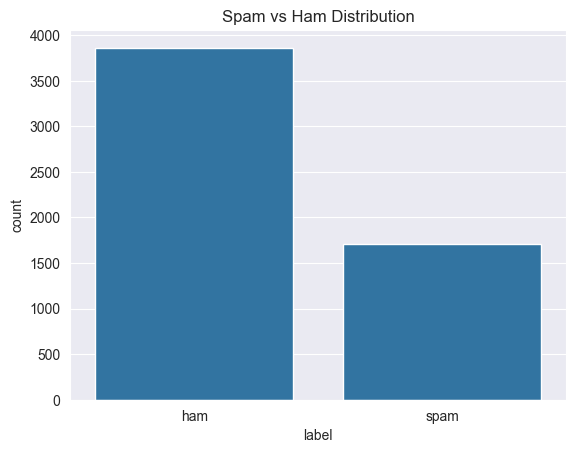

In [116]:
# =========================================================
# VISUALIZE LABEL DISTRIBUTION
# =========================================================

sns.countplot(

    x="label",

    data=df
)

plt.title(

    "Spam vs Ham Distribution"
)

plt.show()

In [117]:
# =========================================================
# EMAIL LENGTH FEATURE
# =========================================================

df["email_length"] = (

    df["body"]

    .apply(len)
)

In [118]:
df["email_length"].describe()

count      5574.000000
mean       2240.636168
std        5703.082226
min          29.000000
25%         616.000000
50%        1092.000000
75%        2026.500000
max      202499.000000
Name: email_length, dtype: float64

In [119]:
# =========================================================
# INSPECT LONGEST EMAIL
# =========================================================

longest_email = df.loc[

    df["email_length"].idxmax()
]

print(

    longest_email["body"][:5000]
)

mv 00001.7c53336b37003a9286aba55d2945844c 00001.7c53336b37003a9286aba55d2945844c
mv 00002.9c4069e25e1ef370c078db7ee85ff9ac 00002.9c4069e25e1ef370c078db7ee85ff9ac
mv 00003.860e3c3cee1b42ead714c5c874fe25f7 00003.860e3c3cee1b42ead714c5c874fe25f7
mv 00004.864220c5b6930b209cc287c361c99af1 00004.864220c5b6930b209cc287c361c99af1
mv 00005.bf27cdeaf0b8c4647ecd61b1d09da613 00005.bf27cdeaf0b8c4647ecd61b1d09da613
mv 00006.253ea2f9a9cc36fa0b1129b04b806608 00006.253ea2f9a9cc36fa0b1129b04b806608
mv 00007.37a8af848caae585af4fe35779656d55 00007.37a8af848caae585af4fe35779656d55
mv 00008.5891548d921601906337dcf1ed8543cb 00008.5891548d921601906337dcf1ed8543cb
mv 00009.371eca25b0169ce5cb4f71d3e07b9e2d 00009.371eca25b0169ce5cb4f71d3e07b9e2d
mv 00010.145d22c053c1a0c410242e46c01635b3 00010.145d22c053c1a0c410242e46c01635b3
mv 00011.fbcde1b4833bdbaaf0ced723edd6e355 00011.fbcde1b4833bdbaaf0ced723edd6e355
mv 00012.48a387bc38d1316a6f6b49e8c2e43a03 00012.48a387bc38d1316a6f6b49e8c2e43a03
mv 00013.81c34741dbed59c6dde

In [120]:
# =========================================================
# LONGEST EMAIL INFORMATION
# =========================================================

print(

    "Label:",
    longest_email["label"]
)

print(

    "\nSubject:",
    longest_email["subject"]
)

print(

    "\nSender:",
    longest_email["from"]
)

print(

    "\nContent Type:",
    longest_email["content_type"]
)

print(

    "\nEmail Length:",
    longest_email["email_length"]
)

Label: ham

Subject: no_subject

Sender: unknown_sender

Content Type: unknown_content_type

Email Length: 202499


In [121]:
# =========================================================
# PREVIEW LONGEST EMAIL
# =========================================================

print(

    longest_email["body"][:10000]
)

mv 00001.7c53336b37003a9286aba55d2945844c 00001.7c53336b37003a9286aba55d2945844c
mv 00002.9c4069e25e1ef370c078db7ee85ff9ac 00002.9c4069e25e1ef370c078db7ee85ff9ac
mv 00003.860e3c3cee1b42ead714c5c874fe25f7 00003.860e3c3cee1b42ead714c5c874fe25f7
mv 00004.864220c5b6930b209cc287c361c99af1 00004.864220c5b6930b209cc287c361c99af1
mv 00005.bf27cdeaf0b8c4647ecd61b1d09da613 00005.bf27cdeaf0b8c4647ecd61b1d09da613
mv 00006.253ea2f9a9cc36fa0b1129b04b806608 00006.253ea2f9a9cc36fa0b1129b04b806608
mv 00007.37a8af848caae585af4fe35779656d55 00007.37a8af848caae585af4fe35779656d55
mv 00008.5891548d921601906337dcf1ed8543cb 00008.5891548d921601906337dcf1ed8543cb
mv 00009.371eca25b0169ce5cb4f71d3e07b9e2d 00009.371eca25b0169ce5cb4f71d3e07b9e2d
mv 00010.145d22c053c1a0c410242e46c01635b3 00010.145d22c053c1a0c410242e46c01635b3
mv 00011.fbcde1b4833bdbaaf0ced723edd6e355 00011.fbcde1b4833bdbaaf0ced723edd6e355
mv 00012.48a387bc38d1316a6f6b49e8c2e43a03 00012.48a387bc38d1316a6f6b49e8c2e43a03
mv 00013.81c34741dbed59c6dde

In [122]:
# =========================================================
# TOP 10 LONGEST EMAILS
# =========================================================

df.sort_values(

    by="email_length",

    ascending=False

)[

    [
        "label",
        "subject",
        "email_length"
    ]

].head(10)

,label,subject,email_length
2500,ham,no_subject,202499
4381,spam,一网“惠”天下，一展天下知----2003年4月1日--4,124923
5798,spam,no_subject,113399
3880,ham,[unison-announce] New unison beta-release (2.9...,108426
3817,ham,"[fm-news] Newsletter for Tuesday, July 30th 2002",89389
676,ham,Re: sed /s/United States/Roman Empire/g,88031
669,ham,sed /s/United States/Roman Empire/g,85698
5480,spam,HAWAI`I & ENENKIO KINGDOMS AMERICANS SHAME !,72559
4145,spam,"LIE`S, MIS-INFORMATION and FRAUD",71524
4452,spam,"Your Membership Community & Commentary, 06-29-01",69213


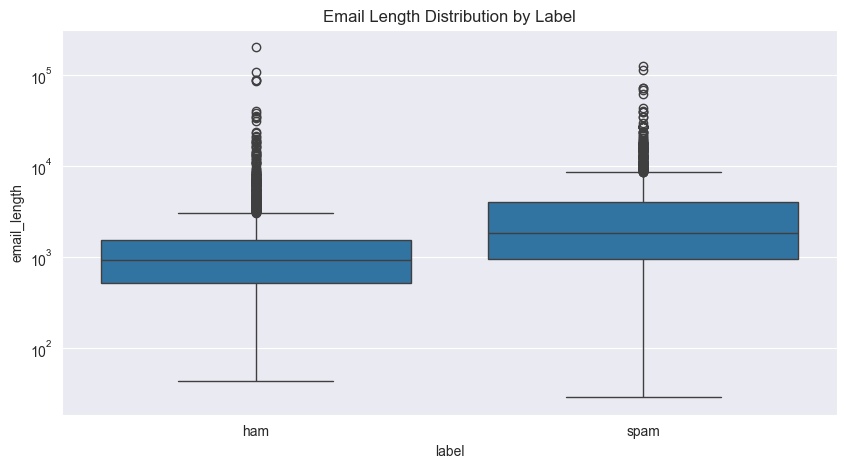

In [123]:
# =========================================================
# EMAIL LENGTH BY LABEL
# =========================================================

plt.figure(figsize=(10, 5))

sns.boxplot(

    x="label",

    y="email_length",

    data=df
)

plt.yscale("log")

plt.title(

    "Email Length Distribution by Label"
)

plt.show()

In [124]:
# =========================================================
# DETECT NON-ASCII EMAILS
# =========================================================

non_ascii_df = df[

    df["body"]

    .str.contains(

        r"[^\x00-\x7F]",

        regex=True,

        na=False
    )
]

print(

    f"Non-ASCII Emails: {len(non_ascii_df)}"
)

non_ascii_df[

    [
        "label",
        "subject"
    ]

].head(10)

Non-ASCII Emails: 66


,label,subject
1305,ham,dvd::rip on Red Hat 8.0?
2560,ham,Re: [ILUG] How to copy some files
2565,ham,Re: [ILUG] How to copy some files
2572,ham,Re: [ILUG] CORRECTION - How to copy some files
2573,ham,Re: [ILUG] hard- vs. soft-links [was: How to c...
2605,ham,Re: [ILUG] How to copy some files
2606,ham,Re: [ILUG] vanquishing the daemons of shell sc...
2610,ham,Re: [ILUG] hard- vs. soft-links [was: How to c...
2690,ham,Re: [ILUG] Piping to multiple processes (which...
2696,ham,Re: [ILUG] inputting chinese characters in Red...


In [125]:
# =========================================================
# CREATE OUTPUT DIRECTORY
# =========================================================

os.makedirs(

    "../data/processed",

    exist_ok=True
)

In [126]:
# =========================================================
# VERIFY DATASET EXPORT
# =========================================================

saved_df = pd.read_csv(

    output_path
)

print(

    saved_df.shape
)

(5767, 8)


In [129]:
df.isnull().sum()

label           0
subject         0
from            0
to              0
date            0
content_type    0
body            0
email_length    0
dtype: int64

In [127]:
saved_df.head()

,label,subject,from,to,date,content_type,body,email_length
0,ham,Re: New Sequences Window,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,"Thu, 22 Aug 2002 18:26:25 +0700","text/plain; charset=""us-ascii""","Date: Wed, 21 Aug 2002 10:54:46 -0500\n...",1598
1,ham,[zzzzteana] RE: Alexander,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...","Thu, 22 Aug 2002 12:46:18 +0100","text/plain; charset=""US-ASCII""","Martin A posted:\nTassos Papadopoulos, the Gre...",894
2,ham,[zzzzteana] Moscow bomber,Tim Chapman <timc@2ubh.com>,zzzzteana <zzzzteana@yahoogroups.com>,"Thu, 22 Aug 2002 13:52:38 +0100","text/plain; charset=""US-ASCII""",Man Threatens Explosion In Moscow \n\nThursday...,1746
3,ham,[IRR] Klez: The Virus That Won't Die,Monty Solomon <monty@roscom.com>,undisclosed-recipient:;,"Thu, 22 Aug 2002 09:15:25 -0400","text/plain; charset=""us-ascii""",Klez: The Virus That Won't Die\n \nAlready the...,1125
4,ham,Re: [zzzzteana] Nothing like mama used to make,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,"Thu, 22 Aug 2002 14:38:22 +0100","text/plain; charset=""US-ASCII""","> in adding cream to spaghetti carbonara, whi...",1047


# Raw Email Parsing Pipeline Summary

## Objective

The goal of this phase was to transform raw email files into a structured machine learning dataset suitable for NLP-based spam classification.

---

## Completed Tasks

### Email Parsing

* loaded raw email files
* parsed MIME email structure
* extracted metadata fields
* extracted email body content
* handled multipart emails
* handled HTML fallback content

### Dataset Construction

* combined ham and spam datasets
* created structured pandas DataFrame
* validated dataset integrity
* exported processed dataset

### Data Quality Handling

* analyzed missing metadata values
* preserved rows using placeholder values
* detected and removed duplicate email bodies
* validated label consistency across duplicates
* removed empty email bodies

### Exploratory Analysis

* analyzed label distribution
* engineered email length feature
* investigated extreme outliers
* explored multilingual and non-ASCII content

---

## Final Dataset

### Dataset Shape

* 5767 emails
* 8 structured features

### Features

* label
* subject
* from
* to
* date
* content_type
* body
* email_length

---

## Key Engineering Insights

* real-world email data is noisy and inconsistent
* MIME parsing is essential for email NLP systems
* duplicate text can create data leakage risks
* missing metadata may contain useful security signals
* outlier investigation should occur before aggressive cleaning
* Unicode detection alone is not sufficient for language identification

---

## Outcome

A clean and structured email dataset is now available for:

* exploratory data analysis
* NLP preprocessing
* feature engineering
* vectorization
* model training
* monitoring workflows
# Parsing Pipeline Summary

## Completed Tasks

- raw email ingestion
- multipart email parsing
- metadata extraction
- body extraction
- duplicate removal
- empty email filtering
- dataset structuring
- processed CSV export

## Output

Structured machine learning dataset ready for:
- exploratory data analysis
- preprocessing
- feature engineering
- model development

In [128]:
saved_df.isnull().sum()

label            0
subject         13
from             1
to              33
date             0
content_type     0
body             0
email_length     0
dtype: int64

In [130]:
df.isnull().sum()

label           0
subject         0
from            0
to              0
date            0
content_type    0
body            0
email_length    0
dtype: int64